# **1. Perkenalan Dataset**


## Sumber Dataset: 
Dataset diperoleh dari kaggle yaitu **Data Bank Transaction Dataset for Fraud Detection** dengan link https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection/data
   
## Tentang Dataset

Dataset ini memberikan wawasan mendalam tentang perilaku transaksi dan pola aktivitas keuangan, yang ideal untuk **mendeteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini berisi **2.512 sampel** data transaksi yang mencakup berbagai atribut transaksi, demografi pelanggan, dan pola penggunaan
#
## Fitur Utama:

- **TransactionID**: ID unik untuk setiap transaksi.
- **AccountID**: ID unik untuk setiap akun (satu akun dapat memiliki banyak transaksi).
- **TransactionAmount**: Jumlah uang dalam transaksi, dari transaksi kecil hingga besar.
- **TransactionDate**: Waktu transaksi yang mencakup tanggal dan jam.
- **TransactionType**: Jenis transaksi, bisa 'Kredit' atau 'Debit'.
- **Location**: Lokasi geografis tempat transaksi dilakukan (nama kota di AS).
- **DeviceID**: ID unik perangkat yang digunakan untuk transaksi.
- **IP Address**: Alamat IP (IPv4) terkait dengan transaksi.
- **MerchantID**: ID unik pedagang tempat transaksi dilakukan.
- **AccountBalance**: Saldo akun setelah transaksi berlangsung.
- **PreviousTransactionDate**: Waktu transaksi sebelumnya untuk analisis frekuensi transaksi.
- **Channel**: Saluran yang digunakan untuk transaksi (misalnya, Online, ATM, Cabang).
- **CustomerAge**: Usia pemegang akun yang dikelompokkan berdasarkan pekerjaan.
- **CustomerOccupation**: Pekerjaan pemegang akun (misalnya, Dokter, Insinyur, Mahasiswa, Pensiunan).
- **TransactionDuration**: Lama waktu transaksi dalam hitungan detik.
- **LoginAttempts**: Jumlah percobaan login sebelum transaksi terjadi (indikatoPada Project ini saya akan menggunakan dataset untuk Clusteringtuk keamanan finansial.


# **2. Import Library**

Import Library yang dibutuhkan

In [180]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# **3. Memuat Dataset**

Dataset yang sudah di download dari kaggle dalam bentuk csv di load menggunakan pandas

In [181]:
# Load dataset
data = pd.read_csv("bank_transactions_data_2.csv")

#Menampilkan data
data

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


# **4. Exploratory Data Analysis (EDA)**

Pada taha EDA ini ada beberapa Hal yang saya lakukan yaitu:
- **Memahami Struktur Data**
- **Analisis Distribusi dan Korelasi**
- **Visualisasi Data**  

## Melihat Sruktur Data

In [182]:
#Informasi Dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

Dataset ini terdiri dari 2.512 baris dan 16 kolom, dengan berbagai tipe data:
- Identitas transaksi: TransactionID, AccountID, MerchantID, DeviceID (semua tipe object).
- Detail transaksi: TransactionAmount (float), TransactionDate (object), TransactionType (object), Location (object), Channel (object).
- Keamanan & perangkat: IP Address (object), LoginAttempts (int), TransactionDuration (int).
- Profil pelanggan: CustomerAge (int), CustomerOccupation (object), AccountBalance (float).
- Riwayat transaksi: PreviousTransactionDate (object).

Tidak Ada Missing Value

In [183]:
# Cek Missing Value
print(data.isnull().sum())

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64


Tidak Ada Missing Value

In [184]:
# Melihat Kolom Kategorik
categorical_columns = data.select_dtypes(include=['object']).columns

# Menampilkan Nilai unik dari kolom kategorik
for col in categorical_columns:
    print(f"{col}: {data[col].nunique()} unique values")
    print(data[col].unique(), "\n")

TransactionID: 2512 unique values
['TX000001' 'TX000002' 'TX000003' ... 'TX002510' 'TX002511' 'TX002512'] 

AccountID: 495 unique values
['AC00128' 'AC00455' 'AC00019' 'AC00070' 'AC00411' 'AC00393' 'AC00199'
 'AC00069' 'AC00135' 'AC00385' 'AC00150' 'AC00459' 'AC00392' 'AC00264'
 'AC00085' 'AC00270' 'AC00317' 'AC00359' 'AC00242' 'AC00285' 'AC00002'
 'AC00014' 'AC00095' 'AC00453' 'AC00241' 'AC00041' 'AC00441' 'AC00057'
 'AC00390' 'AC00313' 'AC00367' 'AC00291' 'AC00060' 'AC00365' 'AC00267'
 'AC00404' 'AC00202' 'AC00478' 'AC00405' 'AC00421' 'AC00480' 'AC00120'
 'AC00117' 'AC00011' 'AC00401' 'AC00282' 'AC00439' 'AC00296' 'AC00471'
 'AC00159' 'AC00482' 'AC00115' 'AC00055' 'AC00419' 'AC00374' 'AC00271'
 'AC00456' 'AC00143' 'AC00427' 'AC00438' 'AC00425' 'AC00325' 'AC00434'
 'AC00319' 'AC00460' 'AC00461' 'AC00395' 'AC00217' 'AC00053' 'AC00110'
 'AC00265' 'AC00239' 'AC00007' 'AC00022' 'AC00464' 'AC00406' 'AC00445'
 'AC00236' 'AC00220' 'AC00140' 'AC00098' 'AC00303' 'AC00373' 'AC00437'
 'AC00106' 

## Statistik Deskriptif

In [185]:
# Analisis Statistik deskriptif
data.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


Insight dari statistik deskriptif:
- TransactionAmount: Rata-rata transaksi sekitar 297.6, dengan variasi yang cukup besar (std 291.95). Ada transaksi sangat kecil (0.26) dan sangat besar (1919.11).
- CustomerAge: Rentang usia pelanggan 18-80 tahun, dengan mayoritas di sekitar 45 tahun.
- TransactionDuration: Durasi transaksi rata-rata sekitar 119.6 detik, dengan maksimum 300 detik.
- LoginAttempts: Sebagian besar pengguna hanya mencoba login sekali (median = 1), tetapi ada beberapa yang mencoba hingga 5 kali.
- AccountBalance: Saldo pelanggan sangat bervariasi, dengan rata-rata 5114.3 dan maksimum hampir 15.000.

### Distribusi Fitur Numerik

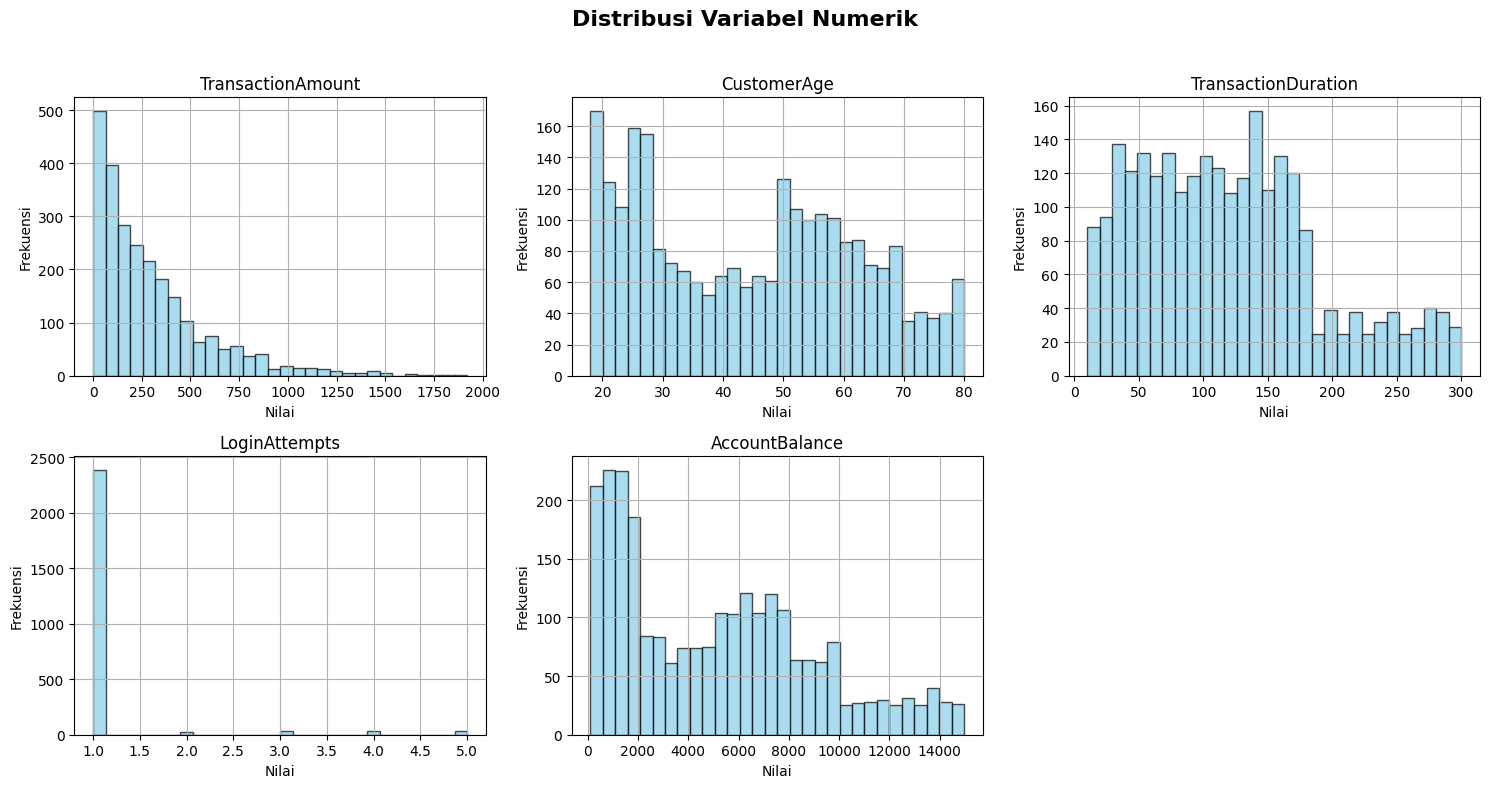

In [186]:
# Menentukan variabel numerik
numerik_cols = data.select_dtypes(include=['float64', 'int64']).columns

# Membuat histogram dengan layout lebih rapi
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
fig.suptitle("Distribusi Variabel Numerik", fontsize=16, fontweight="bold")

# Looping setiap variabel numerik dan menampilkannya di subplot
for ax, col in zip(axes.flatten(), numerik_cols):
    data[col].hist(ax=ax, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Frekuensi")
    ax.set_xlabel("Nilai")

# Menghapus subplot kosong jika ada
for i in range(len(numerik_cols), len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

# Mengatur tata letak agar tidak bertumpuk
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Distribusi Fitur Kategorik

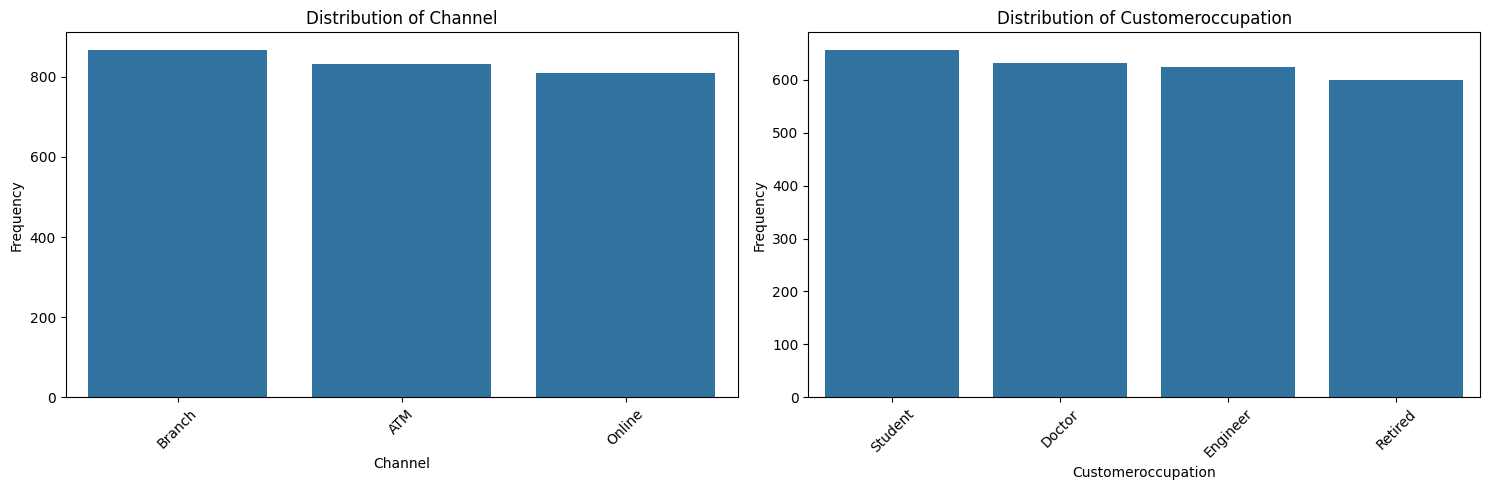

In [187]:
# Pilih kolom kategorikal yang ingin divisualisasikan secara manual
selected_categorical_cols = ['Channel', 'CustomerOccupation']

plt.figure(figsize=(15, 5))

for i, col in enumerate(selected_categorical_cols):
    plt.subplot(1, len(selected_categorical_cols), i+1)  # Menyesuaikan jumlah subplot
    sns.barplot(x=data[col].value_counts().index, y=data[col].value_counts().values)
    plt.title(f'Distribution of {col.replace("_", " ").title()}', size=12)
    plt.xlabel(f'{col.replace("_", " ").title()}')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Visualisasi Data

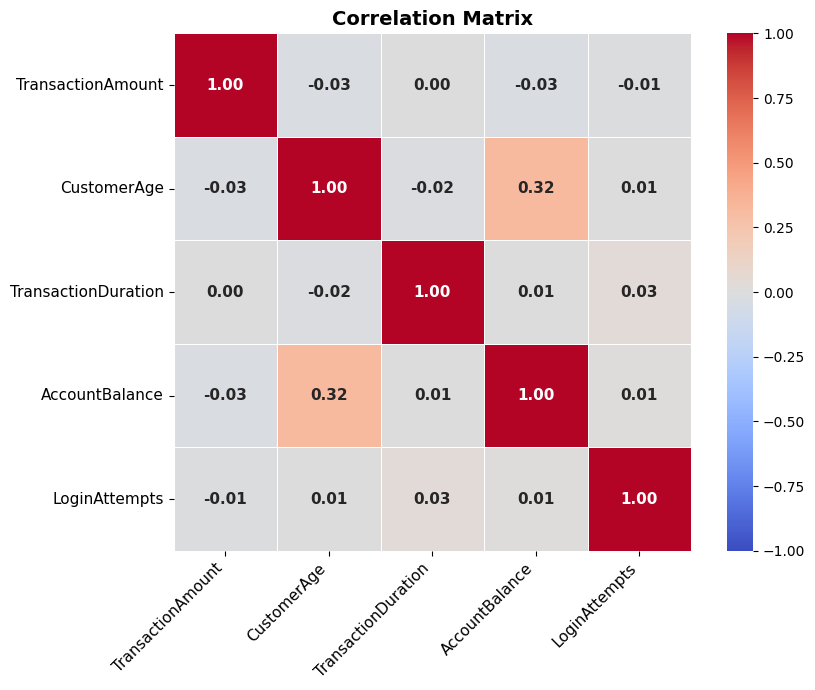

In [188]:
plt.figure(figsize=(9, 7))
sns.heatmap(data[['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance', 'LoginAttempts']].corr(), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            fmt='.2f', annot_kws={'size': 11, 'weight': 'bold'}, linewidths=0.7, linecolor='white', square=True)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.title('Correlation Matrix', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

Ada beberapa tahapan preprocessing yang saya lakukan yaitu sebagai berikut:
1. Menghapus Kolom yang tidak dibutuhkan
2. Mengelompokkan CustomerAge menjadi kategori
3. Label Encoder

### Menghapus Kolom yang tidak dibutuhkan

In [189]:
data = data.drop(columns=['TransactionID', 'TransactionDate', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID'])
data

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,14.09,Debit,San Diego,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,376.24,Debit,Houston,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,126.29,Debit,Mesa,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,184.50,Debit,Raleigh,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,13.45,Credit,Atlanta,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...
2507,856.21,Credit,Colorado Springs,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,251.54,Debit,Tucson,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,28.63,Debit,San Diego,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,185.97,Debit,Denver,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


### Mengelompokkan CustomerAge menjadi kategori

In [190]:
# Definisi rentang umur dan label kategori
bins = [0, 18, 30, 50, 65, 100]  # Rentang umur
labels = ['Remaja', 'Dewasa Muda', 'Dewasa', 'Lansia Muda', 'Lansia']

# Mengganti nilai CustomerAge dengan kategori umur
data["CustomerAge"] = pd.cut(data["CustomerAge"], bins=bins, labels=labels, right=False)

# Menampilkan DataFrame dengan perubahan
data

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,14.09,Debit,San Diego,ATM,Lansia,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,376.24,Debit,Houston,ATM,Lansia,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,126.29,Debit,Mesa,Online,Dewasa Muda,Student,56,1,1122.35,2024-11-04 08:07:04
3,184.50,Debit,Raleigh,Online,Dewasa Muda,Student,25,1,8569.06,2024-11-04 08:09:06
4,13.45,Credit,Atlanta,Online,Dewasa Muda,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...
2507,856.21,Credit,Colorado Springs,Branch,Dewasa,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,251.54,Debit,Tucson,Branch,Dewasa,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,28.63,Debit,San Diego,Branch,Lansia Muda,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,185.97,Debit,Denver,Online,Dewasa Muda,Student,19,1,1776.91,2024-11-04 08:12:22


### Label Encoder

In [191]:
# Melakukan label encoding pada kategori umur
label_encoder = LabelEncoder()
data["CustomerAge"] = label_encoder.fit_transform(data["CustomerAge"])

In [192]:
# pisah kolom numerik dan kategori
object_df = data.select_dtypes(include='object').columns.tolist()
numeric_df = data.select_dtypes(exclude='object').columns.tolist()[:-1]

In [193]:
# Encode the categorical features
df_encoded = data.copy()
for col in object_df:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    
df_encoded.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,14.09,1,36,0,2,0,81,1,5112.21,105
1,376.24,1,15,0,2,0,141,1,13758.91,192
2,126.29,1,23,2,1,3,56,1,1122.35,41
3,184.50,1,33,2,1,3,25,1,8569.06,163
4,13.45,0,1,2,1,3,198,1,7429.40,16


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini model akan dilatih. Algoritma yang saya gunakan adlah K-Means Clustering

In [194]:
X = df_encoded

In [195]:
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

In [196]:
y_pred = kmeans.predict(X)
centroids = kmeans.cluster_centers_

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, saya menggunakan metode Elbow atau Silhouette Score.
1. Elbow Method
2. Hitung Silhouette Score

#### Visualisasi Elbow Method

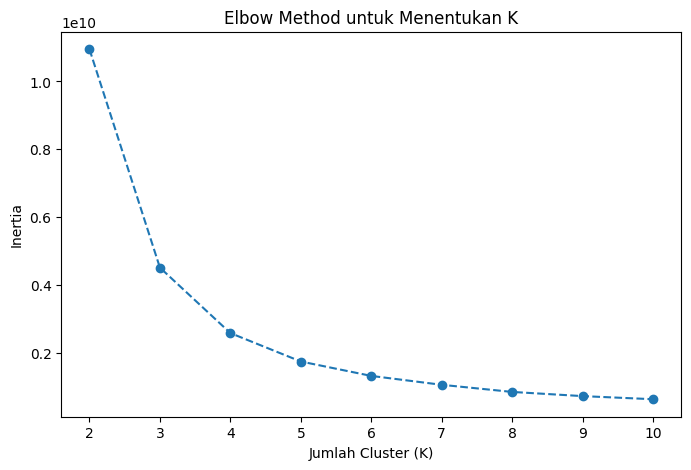

In [197]:
# Mencari jumlah cluster optimal dengan metode Elbow
inertia = []
K_range = range(2, 11)  # Coba jumlah cluster dari 2 hingga 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan K")
plt.show()

Dari Elbow tersebut dapat dilihat bahwa K = 3 adalah yang terbaik

In [198]:
# jumlah cluster terbaik dari Elbow Method 
optimal_k = 3  # sesuai hasil Elbow Method

# Inisialisasi dan fit model K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X["Cluster"] = kmeans.fit_predict(X)

# Cek hasil clustering
print("Jumlah data per cluster:")
print(X["Cluster"].value_counts())

# Tampilkan sample data dengan cluster
X

Jumlah data per cluster:
Cluster
1    1148
2     943
0     421
Name: count, dtype: int64


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Cluster
0,14.09,1,36,0,2,0,81,1,5112.21,105,2
1,376.24,1,15,0,2,0,141,1,13758.91,192,0
2,126.29,1,23,2,1,3,56,1,1122.35,41,1
3,184.50,1,33,2,1,3,25,1,8569.06,163,2
4,13.45,0,1,2,1,3,198,1,7429.40,16,2
...,...,...,...,...,...,...,...,...,...,...,...
2507,856.21,0,7,1,0,0,109,1,12690.79,305,0
2508,251.54,1,40,1,0,0,177,1,254.75,318,1
2509,28.63,1,36,1,3,2,146,1,3382.91,136,1
2510,185.97,1,10,2,1,3,19,1,1776.91,358,1


#### Melihat Silhoutte Score

Silhouette Score untuk k=2: 0.6169
Silhouette Score untuk k=3: 0.6211
Silhouette Score untuk k=4: 0.5929
Silhouette Score untuk k=5: 0.5661
Silhouette Score untuk k=6: 0.5274
Silhouette Score untuk k=7: 0.4699
Silhouette Score untuk k=8: 0.4634
Silhouette Score untuk k=9: 0.4460
Silhouette Score untuk k=10: 0.4310


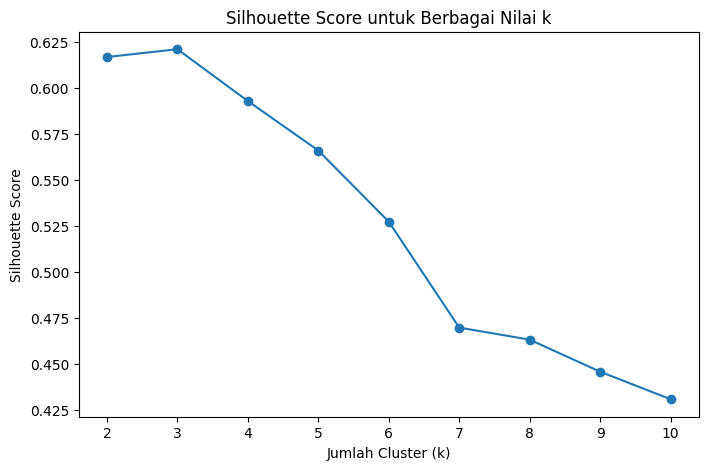

In [199]:
# Rentang nilai k yang akan diuji
k_values = range(2, 11)  # K mulai dari 2 hingga 10
silhouette_scores = []

# Iterasi untuk tiap k
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = model.fit_predict(X.drop(columns=["Cluster"]))  # Lakukan clustering
    
    score = silhouette_score(X.drop(columns=["Cluster"]), cluster_labels)  # Hitung Silhouette Score
    silhouette_scores.append(score)

    print(f"Silhouette Score untuk k={k}: {score:.4f}")

# Visualisasi hasil
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score untuk Berbagai Nilai k")
plt.show()


Dari Evaluasi diatas, maka K yang paling optimal adalah 3 dengan nilai sillhoutte score yaitu 0.6211

## **c. Feature Selection (Opsional)**

Untuk meningkatkan Silhoutte Score kita dapat menggunakan feature Selection, disini kita akan menggunakan SelectKBest

In [200]:
# Tentukan jumlah fitur terbaik yang ingin dipilih (misalnya 5)
k = 5 

# Inisialisasi SelectKBest dengan Mutual Information
selector = SelectKBest(mutual_info_regression, k=k)

# Fit dan transformasi pada data
df_selected = selector.fit_transform(df_encoded.drop(columns=["Cluster"]), df_encoded["Cluster"])

# Ambil fitur yang dipilih
selected_features = df_encoded.drop(columns=["Cluster"]).columns[selector.get_support()]
print("Fitur terpilih:", selected_features)

# Konversi kembali ke DataFrame
df_selected = pd.DataFrame(df_selected, columns=selected_features)


Fitur terpilih: Index(['CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')


In [201]:
# Ulangi proses K-Means dengan data baru (df_selected)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_selected["Cluster"] = kmeans.fit_predict(df_selected)

# Evaluasi ulang dengan Silhouette Score
silhouette_avg = silhouette_score(df_selected.drop(columns=["Cluster"]), df_selected["Cluster"])
print(f"Silhouette Score setelah Feature Selection: {silhouette_avg:.4f}")


Silhouette Score setelah Feature Selection: 0.6365


Silhoutte Score meningkat setelah melakukan Feature Selection sehingga adanya perbandingan antara tanpa menggunakan feature selection, akan tetapi belum mencapai 0,7

## **d. Visualisasi Hasil Clustering**

Visualisasi menggunakan 2D PCA

In [202]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

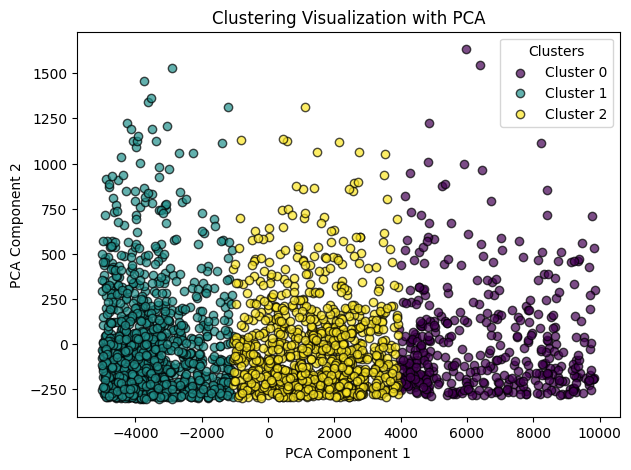

In [203]:
# Dapatkan daftar cluster unik dan warna yang sesuai
clusters = np.unique(y_pred)
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

plt.figure(figsize=(7,5))

# Plot setiap cluster dengan warna dan label yang sesuai
for cluster, color in zip(clusters, colors):
    plt.scatter(X_pca[y_pred == cluster, 0], X_pca[y_pred == cluster, 1], 
                color=color, label=f'Cluster {cluster}', alpha=0.7, edgecolors='k')

# Tambahkan label dan legend
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clustering Visualization with PCA")
plt.legend(title="Clusters")

plt.show()


In [204]:
print("Jumlah data per cluster:")
print(X["Cluster"].value_counts())

Jumlah data per cluster:
Cluster
1    1148
2     943
0     421
Name: count, dtype: int64


## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

#### Menambahkan dan Menyimpan hasil Cluster ke Dataset

In [205]:
# Tambahkan hasil cluster ke df_encoded
df_encoded["Cluster"] = kmeans.labels_

#### Inverse Data

In [206]:
# Mengembalikan (inverse) encoding ke bentuk aslinya
data["CustomerAge"] = label_encoder.inverse_transform(data["CustomerAge"])


In [207]:
# Lakukan inverse transform pada fitur yang telah di-label encoding
for col in data.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    le.fit(data[col])  # Fit encoder dengan data asli sebelum encoding
    data[col] = le.inverse_transform(df_encoded[col])

#### Masukkan Hasil ke data asli

In [208]:
# Masukkan label cluster ke df asli
data["Cluster"] = df_encoded["Cluster"]

# Tampilkan hasil
data

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Cluster
0,14.09,Debit,San Diego,ATM,Lansia,Doctor,81,1,5112.21,2024-11-04 08:08:08,2
1,376.24,Debit,Houston,ATM,Lansia,Doctor,141,1,13758.91,2024-11-04 08:09:35,0
2,126.29,Debit,Mesa,Online,Dewasa Muda,Student,56,1,1122.35,2024-11-04 08:07:04,1
3,184.50,Debit,Raleigh,Online,Dewasa Muda,Student,25,1,8569.06,2024-11-04 08:09:06,2
4,13.45,Credit,Atlanta,Online,Dewasa Muda,Student,198,1,7429.40,2024-11-04 08:06:39,2
...,...,...,...,...,...,...,...,...,...,...,...
2507,856.21,Credit,Colorado Springs,Branch,Dewasa,Doctor,109,1,12690.79,2024-11-04 08:11:29,0
2508,251.54,Debit,Tucson,Branch,Dewasa,Doctor,177,1,254.75,2024-11-04 08:11:42,1
2509,28.63,Debit,San Diego,Branch,Lansia Muda,Retired,146,1,3382.91,2024-11-04 08:08:39,1
2510,185.97,Debit,Denver,Online,Dewasa Muda,Student,19,1,1776.91,2024-11-04 08:12:22,1


### Analisis Karakteristik untuk masing masing cluster

Disini saya akan melihat statistik rata-rata untuk tiap cluster pada kolom numerik dan distribusi kategori pada kolom kategori

In [209]:
# Pisah Kolom Numerik dan Kategori
object_df = data.select_dtypes(include='object').columns.tolist()
numeric_df = data.select_dtypes(exclude='object').columns.tolist()[:-1]

#### Menghitung statistik rata-rata untuk tiap cluster

In [210]:
cluster_summary_numeric = data.groupby("Cluster")[numeric_df].mean()
print(cluster_summary_numeric)


         TransactionAmount  TransactionDuration  LoginAttempts  AccountBalance
Cluster                                                                       
0               304.666952           122.904762       1.169048    11602.938500
1               308.265922           119.538261       1.120000     1580.241600
2               281.411507           118.317410       1.110403     6535.686879


### Melakukan agregasi pada fitur yang sudah diinversi

In [211]:
# Fungsi custom untuk ambil modus
def mode(series):
    return series.mode().iloc[0] if not series.mode().empty else None

# Buat list fitur kategorikal selain PreviousTransactionDate karena bukan kategorik
cat_except_prev_trans = [col for col in object_df if col != 'PreviousTransactionDate']

# Hitung agregasi numerik
numeric_agg = data.groupby("Cluster")[numeric_df].agg(['min', 'max', 'mean'])

# Hitung modus fitur kategorikal
categorical_mode = data.groupby("Cluster")[object_df].agg(mode)

# Hitung frekuensi nilai fitur kategorikal (kecuali PreviousTransactionDate)
categorical_freq = {
    col: data.groupby("Cluster")[col].value_counts().unstack(fill_value=0)
    for col in cat_except_prev_trans
}

# --- TAMPILKAN HASILNYA PER CLUSTER ---
clusters = data['Cluster'].unique()
clusters.sort()

for cluster in clusters:
    print("="*50)
    print(f"Ringkasan untuk Cluster {cluster}")
    print("="*50)

    print("\nFitur Numerik:")
    cluster_numeric = numeric_agg.loc[cluster]
    print(cluster_numeric)

    print("\nModus Fitur Kategorikal:")
    cluster_categorical_mode = categorical_mode.loc[cluster]
    print(cluster_categorical_mode)

    print("\nFrekuensi Nilai Kategorikal (kecuali 'PreviousTransactionDate'):")
    for col in cat_except_prev_trans:
        print(f"\n{col}:")
        print(categorical_freq[col].loc[cluster])
    
    print("\n\n")


Ringkasan untuk Cluster 0

Fitur Numerik:
TransactionAmount    min         1.140000
                     max      1919.110000
                     mean      304.666952
TransactionDuration  min        11.000000
                     max       300.000000
                     mean      122.904762
LoginAttempts        min         1.000000
                     max         5.000000
                     mean        1.169048
AccountBalance       min      9073.170000
                     max     14977.990000
                     mean    11602.938500
Name: 0, dtype: float64

Modus Fitur Kategorikal:
TransactionType                          Debit
Location                               Memphis
Channel                                    ATM
CustomerAge                             Dewasa
CustomerOccupation                      Doctor
PreviousTransactionDate    2024-11-04 08:10:23
Name: 0, dtype: object

Frekuensi Nilai Kategorikal (kecuali 'PreviousTransactionDate'):

TransactionType:
TransactionType

Interpretasi.
1. Cluster 0:
    - Klaster 0 didapatkan karena memiliki rata-rata Account Balance tertinggi sebesar 11,602.94, serta TransactionAmount rata-rata sebesar 304.67. Transaksi pada klaster ini didominasi oleh Debit, dilakukan terutama melalui ATM dan Branch, dan mayoritas penggunanya adalah pelanggan Dewasa yang berprofesi sebagai Doctor.
2. Cluster 1:
   - Klaster 1 terbentuk karena memiliki Account Balance terendah, dengan rata-rata hanya 1,580.24, namun TransactionAmount justru sedikit lebih tinggi dibanding klaster lain. Transaksi juga didominasi oleh Debit dan dilakukan melalui ATM, namun berbeda dengan klaster 0, klaster ini didominasi oleh pelanggan Dewasa Muda yang berprofesi sebagai Student. 
3. Cluster 2:
   - Klaster 2 muncul karena memiliki Account Balance sedang, yaitu rata-rata 6,535.69, dengan TransactionAmount rata-rata paling rendah sebesar 281.41. Transaksi masih didominasi oleh Debit, tetapi dilakukan paling banyak melalui Branch, dan pelanggan utamanya adalah Lansia Muda yang berprofesi sebagai Engineer.

# Analisis Karakteristik Cluster dari Model KMeans  

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.  

## **Cluster 0**  
- **Rata-rata Transaction Amount (USD)** 304.67  
- **Rata-rata Transaction Durationn (detik)** 122.90  
- **Rata-rata Login Attempts:** 1.17  
- **Rata-rata Account Balance (USD):** 11,602.94  

### **Analisis**  
Cluster ini mencakup pelanggan dengan saldo akun tinggi dan jumlah transaksi yang cukup besar. Mayoritas pelanggan adalah **dokter dewasa** yang lebih memilih **ATM** sebagai saluran transaksi utama. Mereka cenderung melakukan transaksi secara efisien tanpa perlu interaksi langsung dengan staf bank.  

---

## **Cluster 1**  
- **Rata-rata Transaction Amount (USD):** 308.27  
- **Rata-rata Transaction Duration (detik):** 119.54  
- **Rata-rata Login Attempts:** 1.12  
- **Rata-rata Account Balance (USD):** 1,580.24  

### **Analisis**  
Cluster ini mencakup pelanggan dari kalangan **anak muda (dewasa muda)** dengan **saldo akun rendah** tetapi **aktif bertransaksi**. Mayoritas pelanggan adalah **mahasiswa** yang lebih banyak menggunakan **ATM** untuk transaksi. Mereka adalah pelanggan yang masih dalam tahap awal karier atau pendidikan, sehingga cocok ditargetkan dengan **produk finansial entry-level atau promo cashback**.  

---

## **Cluster 2**  
- **Rata-rata Transaction Amount (USD):** 281.41  
- **Rata-rata Transaction Duration (detik):** 118.32  
- **Rata-rata Login Attempts:** 1.11  
- **Rata-rata Account Balance (USD):** 6,535.69  

### **Analisis**  
Cluster ini terdiri dari pelanggan dengan saldo akun sedang dan transaksi yang cukup aktif. Mayoritas pelanggan berasal dari **kalangan insinyur dan pensiunan** yang lebih memilih transaksi melalui **cabang bank**. Hal ini menunjukkan bahwa mereka lebih nyaman dengan **interaksi langsung atau layanan personal**, sehingga cocok ditawarkan **layanan konsultasi keuangan atau produk tabungan jangka panjang**.  


# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [212]:
data.to_csv("hasil_clustering_bank.csv", index=False)
print("File 'hasil_clustering_bank.csv' berhasil disimpan!")

File 'hasil_clustering_bank.csv' berhasil disimpan!
